## Imports

In [1]:
%%capture
%pip install numpy
%pip install pandas
%pip install matplotlib.pyplot
%pip install python-terrier

In [2]:
# Load java
!curl -s "https://get.sdkman.io" | bash && source "$HOME/.sdkman/bin/sdkman-init.sh" && sdk install java 11.0.22-amzn < /dev/null

# check java and version
!which java
!java -version
!readlink -f $(which java)
!ls -la /usr/lib/jvm
!java --version
!javac --version


                                -+syyyyyyys:
                            `/yho:`       -yd.
                         `/yh/`             +m.
                       .oho.                 hy                          .`
                     .sh/`                   :N`                `-/o`  `+dyyo:.
                   .yh:`                     `M-          `-/osysoym  :hs` `-+sys:      hhyssssssssy+
                 .sh:`                       `N:          ms/-``  yy.yh-      -hy.    `.N-````````+N.
               `od/`                         `N-       -/oM-      ddd+`     `sd:     hNNm        -N:
              :do`                           .M.       dMMM-     `ms.      /d+`     `NMMs       `do
            .yy-                             :N`    ```mMMM.      -      -hy.       /MMM:       yh
          `+d+`           `:/oo/`       `-/osyh/ossssssdNMM`           .sh:         yMMN`      /m.
         -dh-           :ymNMMMMy  `-/shmNm-`:N/-.``   `.sN            /N-         `NMMy      .m/
  

In [3]:
import json
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyterrier as pt
from pathlib import Path
from tqdm import tqdm

## Load dataset

In [4]:
base = 'https://raw.githubusercontent.com/Legenden84/search-engines/master/project_handout'

docs    = pd.read_json(f'{base}/docs2.jsonl', lines=True, dtype={'docno': str})
queries = pd.read_csv(f'{base}/train_queries.csv')
qrels   = pd.read_csv(f'{base}/train_qrels.csv')

## Verify dataset

In [5]:
print(docs.shape)
docs.sample(5, random_state=42)

(151993, 2)


,docno,text
114980,D114980,Italian Renaissance The Italian Renaissance (I...
88715,D88715,2018–19 NCAA Division I men's basketball seaso...
38065,D38065,Mount St. Helens Mount St. Helens or Louwala-C...
16042,D16042,Bachelor in Paradise (season 5) The fifth seas...
49231,D49231,I Could Use a Love Song The music video of the...


In [6]:
print(queries.shape)
queries.sample(5)

(10000, 2)


,qid,text
3980,3980,who played mr. furley on three's company
9145,9145,fear the walking dead season 3 new characters
1921,1921,where are tropical evergreen forests found in ...
225,225,the major spacecraft launching centre in south...
2774,2774,where does the phrase pork chops and applesauc...


In [7]:
print(qrels.shape)
qrels.sample(5)

(17746, 4)


,qid,docno,relevance,iteration
10206,248,D86944,2,0
669,1202,D5722,2,0
14457,9076,D123971,2,0
10632,4675,D90711,1,0
16592,4071,D141677,2,0


In [8]:
print('Unique labels: \n', qrels['relevance'].unique())
print('\n')
print('Distribution of labels: \n', qrels[['qid','relevance']].groupby(by='relevance').count().reset_index())

Unique labels: 
 [2 1]


Distribution of labels: 
    relevance    qid
0          1   7746
1          2  10000


In [9]:
print(qrels[qrels['relevance'] == 2])

        qid    docno  relevance  iteration
0      5743       D2          2          0
1      6266      D13          2          0
2      7918      D17          2          0
6      5246      D73          2          0
8      9909      D83          2          0
...     ...      ...        ...        ...
17738  1703  D151968          2          0
17740  6956  D151976          2          0
17742  7811  D151981          2          0
17743  8331  D151982          2          0
17745  6556  D151991          2          0

[10000 rows x 4 columns]


In [10]:
qid = 8030

# Sneak peak into the query for qid D127677
qrels_for_qid = qrels[qrels['qid'] == qid]
print(qrels_for_qid)

# Sneak peak into document highly relevant for qid D127677
print('\nQuery')
print(queries.loc[queries['qid'] == qid, 'text'].iloc[0])

# Sneak peak into document somwwhat relevant for qid D127677
docno = qrels_for_qid.sort_values('relevance', ascending=False)['docno'].iloc[0]

print(f'\nRelevant document for qid {qid}: {docno}')
print(docs.loc[docs["docno"] == docno, "text"].iloc[0])

        qid    docno  relevance  iteration
15853  8030  D135228          2          0

Query
what was the first hotel casino in las vegas

Relevant document for qid 8030: D135228
Las Vegas Strip The first casino to be built on Highway 91 was the Pair-o-Dice Club in 1931, but the first resort on what is currently the Strip was the El Rancho Vegas, opening on April 3, 1941, with 63 rooms. That casino/ resort stood for almost 20 years before being destroyed by a fire in 1960. Its success spawned a second hotel on what would become the Strip, the Hotel Last Frontier, in 1942. Organized crime figures such as New York's Bugsy Siegel took interest in the growing gaming center leading to other resorts such as the Flamingo, which opened in 1946, and the Desert Inn, which opened in 1950. The funding for many projects was provided through the American National Insurance Company, which was based in the then notorious gambling empire of Galveston, Texas.[9][10]


## 2.1 Dataset

In [11]:
doc_lengths = docs["text"].str.split().str.len()
query_lengths = queries["text"].str.split().str.len()

res = pd.DataFrame({
    "total": [len(query_lengths), len(doc_lengths)],
    "min": [query_lengths.min(), doc_lengths.min()],
    "max": [query_lengths.max(), doc_lengths.max()],
    "median": [query_lengths.median(), doc_lengths.median()],
    "average": [query_lengths.mean(), doc_lengths.mean()]
}, index=["queries", "documents"])

res

,total,min,max,median,average
queries,10000,5,23,9.0,9.080600
documents,151993,1,2219,82.0,91.458784


## 2.1: Plot statistics

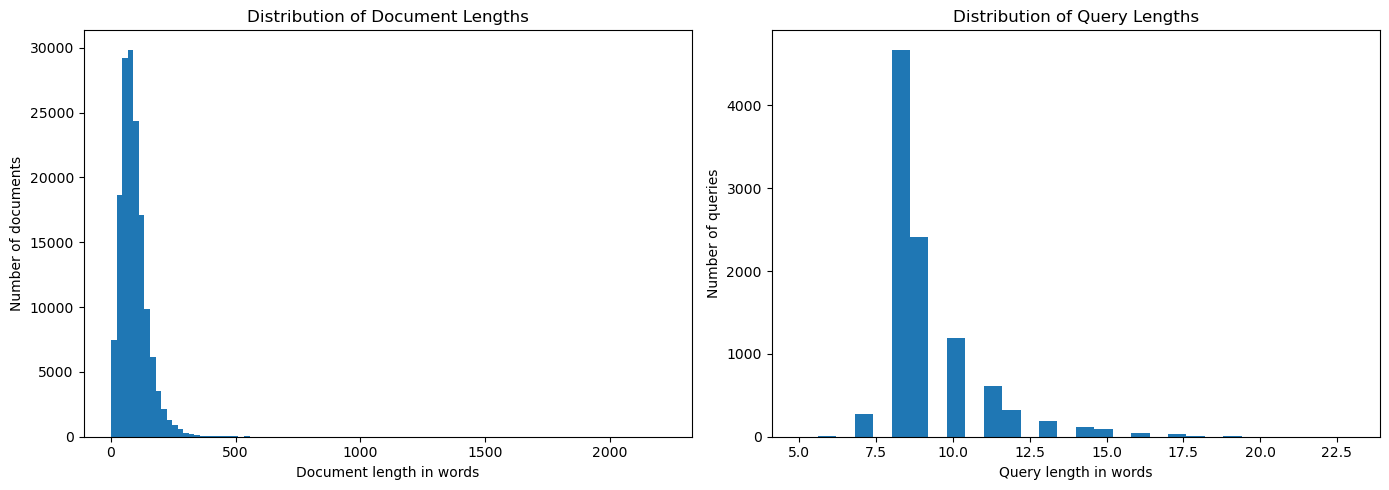

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Document length distribution
axes[0].hist(doc_lengths, bins=100)
axes[0].set_title("Distribution of Document Lengths")
axes[0].set_xlabel("Document length in words")
axes[0].set_ylabel("Number of documents")

# Query length distribution
axes[1].hist(query_lengths, bins=30)
axes[1].set_title("Distribution of Query Lengths")
axes[1].set_xlabel("Query length in words")
axes[1].set_ylabel("Number of queries")

plt.tight_layout()
plt.show()

## PyTerrier

In [17]:
!find /usr/lib/jvm -name "libjvm.so" 2>/dev/null

/usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so
/usr/lib/jvm/java-25-openjdk-amd64/lib/server/libjvm.so


### PyTerrier local

In [18]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["JVM_PATH"] = "/usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

import pyterrier as pt

if not pt.java.started():
    pt.java.init()

print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("JVM_PATH:", os.environ["JVM_PATH"])
print("Java started:", pt.java.started())

JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
JVM_PATH: /usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so
Java started: True


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


In [ ]:
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
# os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# if not pt.started():
#     pt.init()

# print("JAVA_HOME:", os.environ["JAVA_HOME"])
# print("Java started:", pt.java.started())

## 2.2 Build Indexes

In [19]:
index_path_default = "./indexes/default"
index_path_default_obj = Path(index_path_default)

if (index_path_default_obj / "data.properties").exists():
    print(f"Default index already exists at {index_path_default}. Loading without rebuilding.")

    index_ref = index_path_default
    index = pt.IndexFactory.of(index_ref)

else:
    print(f"Default index does not exist at {index_path_default}. Building index.")

    indexer = pt.IterDictIndexer(index_path_default, overwrite=True)
    index_ref = indexer.index(docs.to_dict(orient="records"))
    index = pt.IndexFactory.of(index_ref)

    print(f"Built default index at {index_path_default}")

print("Default index statistics:")
print(index.getCollectionStatistics().toString())

Default index does not exist at ./indexes/default. Building index.
Built default index at ./indexes/default
Default index statistics:
Number of documents: 151993
Number of terms: 124533
Number of postings: 6389931
Number of fields: 0
Number of tokens: 8423338
Field names: []
Positions:   false



In [20]:
# Where does 'agenda' appear?
pointer = index.getLexicon()["agenda"]
print("Pointer: ", pointer)
for posting in index.getInvertedIndex().getPostings(pointer):
    print(f"{posting.toString()} doclen={posting.getDocumentLength()}")

Pointer:  term1186 Nt=94 TF=107 maxTF=2147483647 @{0 1092621 5}
ID(39) TF(1) doclen=41
ID(991) TF(4) doclen=39
ID(2341) TF(3) doclen=41
ID(3059) TF(1) doclen=67
ID(4389) TF(1) doclen=110
ID(5787) TF(1) doclen=62
ID(9143) TF(1) doclen=69
ID(11489) TF(1) doclen=61
ID(14860) TF(1) doclen=62
ID(16233) TF(1) doclen=86
ID(19621) TF(3) doclen=41
ID(19897) TF(1) doclen=61
ID(20135) TF(1) doclen=68
ID(21068) TF(1) doclen=41
ID(21335) TF(1) doclen=42
ID(21422) TF(1) doclen=95
ID(23838) TF(1) doclen=50
ID(25534) TF(1) doclen=47
ID(25669) TF(1) doclen=89
ID(26140) TF(1) doclen=87
ID(27337) TF(1) doclen=55
ID(27369) TF(1) doclen=40
ID(30083) TF(1) doclen=89
ID(32478) TF(1) doclen=41
ID(34664) TF(1) doclen=47
ID(34703) TF(1) doclen=96
ID(34825) TF(1) doclen=41
ID(35719) TF(1) doclen=81
ID(36910) TF(1) doclen=81
ID(47190) TF(1) doclen=61
ID(52318) TF(1) doclen=47
ID(52849) TF(1) doclen=47
ID(54718) TF(1) doclen=54
ID(55024) TF(1) doclen=54
ID(55034) TF(1) doclen=45
ID(57200) TF(1) doclen=88
ID(57286)

### 2.2.1 Full index

In [21]:
index_path_none = "./indexes/full"
index_path_none_obj = Path(index_path_none)

build_time_path_none = index_path_none_obj / "build_time.json"

if index_path_none_obj.exists():
    print(f"Index already exists at {index_path_none}. Loading without rebuilding.")

    index_none = pt.IndexFactory.of(index_path_none)

    if build_time_path_none.exists():
        with open(build_time_path_none, "r") as f:
            build_time_index_none = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_none:.2f}s")
    else:
        build_time_index_none = None
        print("No preserved build time found.")

else:
    print(f"Index does not exist at {index_path_none}. Building index.")

    start_time_index_none = time.perf_counter()

    indexer_none = pt.IterDictIndexer(
        index_path_none,
        overwrite=True,
        stopwords=None,
        stemmer=None
    )

    index_ref_none = indexer_none.index(docs.to_dict(orient="records"))
    index_none = pt.IndexFactory.of(index_ref_none)

    end_time_index_none = time.perf_counter()
    build_time_index_none = end_time_index_none - start_time_index_none

    with open(build_time_path_none, "w") as f:
        json.dump(
            {
                "description": "Full index",
                "build_time_milliseconds": build_time_index_none
            },
            f,
            indent=4
        )

    print(f"Built index and saved build time: {build_time_index_none:.2f}s")

# Validate loaded/built index
stats_stop = index_none.getCollectionStatistics()

Index does not exist at ./indexes/full. Building index.


Built index and saved build time: 13.60s


### 2.2.2 Stopwords removed

In [22]:
index_path_stop = "./indexes/stopwords"
index_path_stop_obj = Path(index_path_stop)

build_time_path_stop = index_path_stop_obj / "build_time.json"

if (index_path_stop_obj / "data.properties").exists():
    print(f"Stopwords index already exists at {index_path_stop}. Loading without rebuilding.")

    index_stop = pt.IndexFactory.of(index_path_stop)

    if build_time_path_stop.exists():
        with open(build_time_path_stop, "r") as f:
            build_time_index_stop = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_stop:.2f}s")
    else:
        build_time_index_stop = None
        print("No preserved build time found.")

else:
    print(f"Stopwords index does not exist at {index_path_stop}. Building index.")

    start_time_index_stop = time.perf_counter()

    indexer_stop = pt.IterDictIndexer(
        index_path_stop,
        overwrite=True,
        stopwords="terrier",
        stemmer=None
    )

    index_ref_stop = indexer_stop.index(docs.to_dict(orient="records"))
    index_stop = pt.IndexFactory.of(index_ref_stop)

    end_time_index_stop = time.perf_counter()
    build_time_index_stop = end_time_index_stop - start_time_index_stop

    with open(build_time_path_stop, "w") as f:
        json.dump(
            {
                "description": "Stopwords removed, no stemming",
                "build_time_milliseconds": build_time_index_stop
            },
            f,
            indent=4
        )

    print(f"Built stopwords index and saved build time: {build_time_index_stop:.2f}s")

# Validate loaded/built index
stats_stop = index_stop.getCollectionStatistics()

Stopwords index does not exist at ./indexes/stopwords. Building index.
Built stopwords index and saved build time: 11.66s


### 2.2.3 Stemming

In [23]:
index_path_stem = "./indexes/stemming"
index_path_stem_obj = Path(index_path_stem)

build_time_path_stem = index_path_stem_obj / "build_time.json"

if (index_path_stem_obj / "data.properties").exists():
    print(f"Stemming index already exists at {index_path_stem}. Loading without rebuilding.")

    index_stem = pt.IndexFactory.of(index_path_stem)

    if build_time_path_stem.exists():
        with open(build_time_path_stem, "r") as f:
            build_time_index_stem = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_stem:.2f}s")
    else:
        build_time_index_stem = None
        print("No preserved build time found.")

else:
    print(f"Stemming index does not exist at {index_path_stem}. Building index.")

    start_time_index_stem = time.perf_counter()

    indexer_stem = pt.IterDictIndexer(
        index_path_stem,
        overwrite=True,
        stopwords=None,
        stemmer="porter"
    )

    index_ref_stem = indexer_stem.index(docs.to_dict(orient="records"))
    index_stem = pt.IndexFactory.of(index_ref_stem)

    end_time_index_stem = time.perf_counter()
    build_time_index_stem = end_time_index_stem - start_time_index_stem

    with open(build_time_path_stem, "w") as f:
        json.dump(
            {
                "description": "No stopwords removed, Porter stemming",
                "build_time_milliseconds": build_time_index_stem
            },
            f,
            indent=4
        )

    print(f"Built stemming index and saved build time: {build_time_index_stem:.2f}s")

# Validate loaded/built index
stats_stem = index_stem.getCollectionStatistics()

Stemming index does not exist at ./indexes/stemming. Building index.
Built stemming index and saved build time: 12.95s


### 2.2.4 Stopwords and Stemming

In [24]:
index_path_stop_stem = "./indexes/stop-stem"
index_path_stop_stem_obj = Path(index_path_stop_stem)

build_time_path_stop_stem = index_path_stop_stem_obj / "build_time.json"

if (index_path_stop_stem_obj / "data.properties").exists():
    print(f"Stopwords + stemming index already exists at {index_path_stop_stem}. Loading without rebuilding.")

    index_stop_stem = pt.IndexFactory.of(index_path_stop_stem)

    if build_time_path_stop_stem.exists():
        with open(build_time_path_stop_stem, "r") as f:
            build_time_index_stop_stem = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_stop_stem:.2f}s")
    else:
        build_time_index_stop_stem = None
        print("No preserved build time found.")

else:
    print(f"Stopwords + stemming index does not exist at {index_path_stop_stem}. Building index.")

    start_time_index_stop_stem = time.perf_counter()

    indexer_stop_stem = pt.IterDictIndexer(
        index_path_stop_stem,
        overwrite=True,
        stopwords="terrier",
        stemmer="porter"
    )

    index_ref_stop_stem = indexer_stop_stem.index(docs.to_dict(orient="records"))
    index_stop_stem = pt.IndexFactory.of(index_ref_stop_stem)

    end_time_index_stop_stem = time.perf_counter()
    build_time_index_stop_stem = end_time_index_stop_stem - start_time_index_stop_stem

    with open(build_time_path_stop_stem, "w") as f:
        json.dump(
            {
                "description": "Stopwords removed, Porter stemming",
                "build_time_milliseconds": build_time_index_stop_stem
            },
            f,
            indent=4
        )

    print(f"Built stopwords + stemming index and saved build time: {build_time_index_stop_stem:.2f}s")

# Validate loaded/built index
stats_stop_stem = index_stop_stem.getCollectionStatistics()

Stopwords + stemming index does not exist at ./indexes/stop-stem. Building index.
Built stopwords + stemming index and saved build time: 11.68s


In [26]:
index_none.getLexicon()["the"].toString()

'term14 Nt=145101 TF=1099981 maxTF=2147483647 @{0 13198780 5}'

## Index statistics

In [27]:
print("* Index: Full")
print(index_none.getCollectionStatistics().toString())


* Index: Full
Number of documents: 151993
Number of terms: 160176
Number of postings: 9518322
Number of fields: 0
Number of tokens: 14483146
Field names: []
Positions:   false



In [28]:
print("* Index: Stopwords removed")
print(index_stop.getCollectionStatistics().toString())

* Index: Stopwords removed
Number of documents: 151993
Number of terms: 159671
Number of postings: 6605870
Number of fields: 0
Number of tokens: 8423338
Field names: []
Positions:   false



In [29]:
print("* Index: Stemming only")
print(index_stem.getCollectionStatistics().toString())

* Index: Stemming only
Number of documents: 151993
Number of terms: 124796
Number of postings: 9263034
Number of fields: 0
Number of tokens: 14483146
Field names: []
Positions:   false



In [30]:
print("* Index: Stopwords removed and stemming")
print(index_stop_stem.getCollectionStatistics().toString())

* Index: Stopwords removed and stemming
Number of documents: 151993
Number of terms: 124533
Number of postings: 6389931
Number of fields: 0
Number of tokens: 8423338
Field names: []
Positions:   false



In [31]:
!du -s indexes/*

49924	indexes/default
61148	indexes/full
55072	indexes/stemming
49928	indexes/stop-stem
55708	indexes/stopwords


In [32]:
# Helper: calculate index folder size
def get_folder_size_mb(path):
    total_size = 0

    for dirpath, _, filenames in os.walk(path):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)
            if os.path.isfile(filepath):
                total_size += os.path.getsize(filepath)

    return total_size / (1024 ** 2)

In [33]:
# Helper: calculate average search time
def get_average_search_time(index, queries_df, wmodel="BM25"):
    retriever = pt.terrier.Retriever(index, wmodel=wmodel)

    query_times_ms = []

    for _, row in queries_df.iterrows():
        single_query = pd.DataFrame([{
            "qid": str(row["qid"]),
            "query": row["text"]
        }])

        start = time.perf_counter()
        _ = retriever.transform(single_query)
        end = time.perf_counter()

        query_times_ms.append((end - start) * 1000)

    return sum(query_times_ms) / len(query_times_ms)

In [34]:
# Helper
def read_build_time(index_path):
    build_time_path = Path(index_path) / "build_time.json"

    if not build_time_path.exists():
        return None

    with open(build_time_path, "r") as file:
        return round(json.load(file)["build_time_milliseconds"], 1)

In [35]:
# Collect indexes
indexes = {
    "index_none": {
        "index": index_none,
        "path": "./indexes/full",
        "description": "No stopword removal, no stemming",
        "build_time": read_build_time("./indexes/full")
    },
    "index_stop": {
        "index": index_stop,
        "path": "./indexes/stopwords",
        "description": "Stopword removal only",
        "build_time": read_build_time("./indexes/stopwords")
    },
    "index_stem": {
        "index": index_stem,
        "path": "./indexes/stemming",
        "description": "Stemming only",
        "build_time": read_build_time("./indexes/stemming")
    },
    "index_stop_stem": {
        "index": index_stop_stem,
        "path": "./indexes/stop-stem",
        "description": "Stopword removal and stemming",
        "build_time": read_build_time("./indexes/stop-stem")
    }
}

In [36]:
report_cache_path = Path("./indexes/report_table_rows.json")

if report_cache_path.exists():
    print(f"Loading cached report table rows from {report_cache_path}")

    with open(report_cache_path, "r") as file:
        rows = json.load(file)

else:
    print("No cached report table found. Computing report table rows...")

    rows = []

    for index_name, index_info in indexes.items():
        index = index_info["index"]
        stats = index.getCollectionStatistics()

        print(f"Computing: {index_name}...")

        rows.append({
            "Index version": index_name,
            "Description": index_info["description"],
            "Number of documents indexed": stats.getNumberOfDocuments(),
            "Number of unique terms": stats.getNumberOfUniqueTerms(),
            "Total number of tokens": stats.getNumberOfTokens(),
            "Index storage size (MB)": round(get_folder_size_mb(index_info["path"]), 1),
            "Build time (seconds)": index_info["build_time"],
            "Average search time per query (milli-seconds)": round(get_average_search_time(index, queries), 3)
        })

    with open(report_cache_path, "w") as file:
        json.dump(rows, file, indent=4)

    print(f"Saved report table rows to {report_cache_path}")

table = pd.DataFrame(rows)

No cached report table found. Computing report table rows...
Computing: index_none...
Computing: index_stop...
Computing: index_stem...
Computing: index_stop_stem...
Saved report table rows to indexes/report_table_rows.json


In [37]:
table

,Index version,Description,Number of documents indexed,Number of unique terms,Total number of tokens,Index storage size (MB),Build time (seconds),Average search time per query (milli-seconds)
0,index_none,"No stopword removal, no stemming",151993,160176,14483146,59.7,13.6,21.229
1,index_stop,Stopword removal only,151993,159671,8423338,54.4,11.7,10.674
2,index_stem,Stemming only,151993,124796,14483146,53.8,13.0,21.691
3,index_stop_stem,Stopword removal and stemming,151993,124533,8423338,48.7,11.7,10.885


# Ranking models and Evaluation

In [38]:
# First, lets build a map from docid (0-based) to docno.
indexStats = index.getCollectionStatistics()
metaIndex = index.getMetaIndex()
docid2docno = {i: metaIndex.getItem("docno", i) for i in range(indexStats.getNumberOfDocuments())}

# We can fix also the scalar N
N = indexStats.getNumberOfDocuments()
print(f'N = {N}')

N = 151993


In [39]:
# indexStats gives you statistics about the index
print("====================== INDEXSTATS =========================")
print(indexStats)

====================== INDEXSTATS =========================
Number of documents: 151993
Number of terms: 124533
Number of postings: 6389931
Number of fields: 0
Number of tokens: 8423338
Field names: []
Positions:   false



In [40]:
# Lets print first 5 items in the docid2docno dictionary
count = 0
for docid, docno in docid2docno.items():
    print("docid: {docid} docno: {docno}".format(docid=docid, docno=docno))
    count += 1
    if count >=5:
        break

# Length of this dictionary should be equal to the number of documents
print("Number of documents: ", len(docid2docno))

docid: 0 docno: D0
docid: 1 docno: D1
docid: 2 docno: D2
docid: 3 docno: D3
docid: 4 docno: D4
Number of documents:  151993


In [ ]:
# Lexicon gives you information about the vocabulary (from Lab 1)
lexicon = index.getLexicon()

# Retrieve term statistics appearing in indices (1900, 1905)
ix_range = range(1900, 1905)
for ix, kv in enumerate(index.getLexicon()):
    if ix in ix_range:
        print(f"{kv.getKey()} -> {kv.getValue().toString()}")
    elif ix > ix_range[-1]:
        break

2117 -> term122885 Nt=1 TF=1 maxTF=2147483647 @{0 547577 7}
211feet -> term106016 Nt=1 TF=1 maxTF=2147483647 @{0 547582 3}
211th -> term72618 Nt=1 TF=1 maxTF=2147483647 @{0 547586 5}
212 -> term31600 Nt=77 TF=79 maxTF=2147483647 @{0 547590 5}
2121 -> term117359 Nt=1 TF=1 maxTF=2147483647 @{0 547797 1}


In [ ]:
lexicon = index.getLexicon()
direct_index = index.getDirectIndex()
document_index = index.getDocumentIndex()

N_t = np.zeros(len(lexicon), dtype=np.int32)

for docid in tqdm(list(docid2docno.keys())):
    doc_entry = document_index.getDocumentEntry(docid)

    for posting in direct_index.getPostings(doc_entry):
        termid = posting.getId()
        N_t[termid] += 1

print(f"N_t = {N_t}")
print("Shape of N_t:", N_t.shape)

# lexicon = index.getLexicon()

# This is our frequency term document matrix, we initialize all cells to zeros.
# freq_term_doc = np.zeros((len(lexicon), N), dtype=int)

# # Iterate over document IDs, retrieve its terms and update term_doc_matrix.
# direct_index = index.getDirectIndex()
# document_index = index.getDocumentIndex()

# # Loop over every document in the index by its numeric ID (0-based)
# for docid in tqdm(list(docid2docno.keys())):

#     # document_index.getDocumentEntry(docid) retrieves the metadata/entry
#     # for this document, which the direct index needs to locate its postings.
#     #
#     # direct_index.getPostings(...) then returns an iterator over all terms
#     # that appear in this document. Each "posting" represents one term and
#     # holds info like the term's ID and how often it occurs in this document.
#     for posting in direct_index.getPostings(document_index.getDocumentEntry(docid)):

#         # posting.getId() returns the numeric term ID (row in our matrix)
#         termid = posting.getId()

#         # posting.getFrequency() returns how many times this term appears
#         # in this document, giving us the raw term frequency f_{t,d}
#         freq_term_doc[termid, docid] = posting.getFrequency()

100%|████████████████████████████████████████████████████████████████████████| 151993/151993 [00:11<00:00, 13168.51it/s]

N_t = [4503 1537   10 ...    1    1    1]
Shape of N_t: (124533,)


In [38]:
print("Shape of the matrix: ", freq_term_doc.shape)
print("Maximum frequency: ", freq_term_doc.max())
print(freq_term_doc)

Shape of the matrix:  (124533, 151993)
Maximum frequency:  51
[[1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [3 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [22]:
# To get N_t we just sum across columns using a binary indicator
# N_t = np.count_nonzero(freq_term_doc, axis=1)

# print("Shape of N_t:", N_t.shape)
# print("First 10 N_t values:", N_t[:10])
# print("Max N_t:", N_t.max())

# To get N_t we just sum across columns using a binary indicator
N_t = (freq_term_doc > 0).sum(axis=1)
print(f'N_t = {N_t}')
print("Shape of N_t: ", N_t.shape)

NameError: name 'freq_term_doc' is not defined

In [ ]:
len(np.nonzero(freq_term_doc)[0]) == indexStats.numberOfPointers